!pip install --upgrade pip
!pip install --upgrade setuptools

!pip install pandas whois httpx
!pip install pycaret 
!pip install xgboost

In [1]:
!pip install gradio


[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install selenium


[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
!pip install pycaret


[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd # use for data manipulation and analysis
import numpy as np # use for multi-dimensional array and matrix

import seaborn as sns # use for high-level statistical graphics 
import matplotlib.pyplot as plt # It provides an object-oriented API 
%matplotlib inline 
# It sets the backend of matplotlib to the 'inline' backend:
import time # calculate time 
import warnings # ignores pink warnings 
warnings.filterwarnings('ignore')

In [6]:
phish_data = pd.read_csv('phishing_site_urls.csv')

In [7]:
phish_data.sample(5)

,URL,Label
468429,yellowglenusa.com/sparkling-wine-winemaker.html,good
107515,poolscene.ca/za/590d9a291a7ef582c73f36a2f1108573,bad
199057,ibnlive.in.com/news/bipasha-goes-gaga-over-abh...,good
526379,ssl.exemail.net:443/hnwy/index.php?id=3999444843,bad
185230,eventful.com/performers/eric-gales-/P0-001-000...,good


In [8]:
phish_data.head()

,URL,Label
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad
3,mail.printakid.com/www.online.americanexpress....,bad
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad


In [9]:
phish_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 549346 entries, 0 to 549345
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   URL     549346 non-null  object
 1   Label   549346 non-null  object
dtypes: object(2)
memory usage: 8.4+ MB


In [10]:
phish_data.isnull().sum() 

URL      0
Label    0
dtype: int64

In [11]:
#create a dataframe of classes counts
label_counts = pd.DataFrame(phish_data.Label.value_counts())

In [12]:
label_counts

,count
Label,
good,392924
bad,156422


In [13]:
# Map 'good' to 0 and 'bad' to 1
#phish_data['Label'] = phish_data['Label'].map({'good': 0, 'bad': 1})

# Verify the change
phish_data.Label.value_counts()

Label
good    392924
bad     156422
Name: count, dtype: int64

In [14]:
##the labels have turned into 0 and 1 from good to bad so the previous code was another 

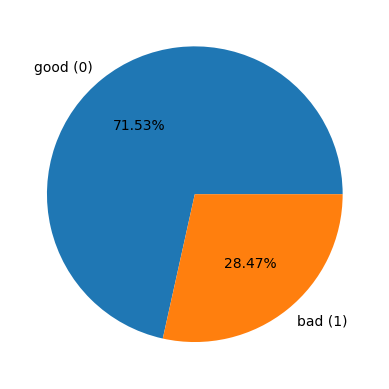

In [15]:
plt.pie(phish_data['Label'].value_counts(), 
        labels=['good (0)', 'bad (1)'], 
        autopct="%0.2f%%")
plt.show()

In [16]:
from nltk.tokenize import RegexpTokenizer


In [17]:
tokenizer = RegexpTokenizer(r'[A-Za-z]+')

In [18]:
phish_data.URL[0]

'nobell.it/70ffb52d079109dca5664cce6f317373782/login.SkyPe.com/en/cgi-bin/verification/login/70ffb52d079109dca5664cce6f317373/index.php?cmd=_profile-ach&outdated_page_tmpl=p/gen/failed-to-load&nav=0.5.1&login_access=1322408526'

In [19]:
tokenizer.tokenize(phish_data.URL[0])

['nobell',
 'it',
 'ffb',
 'd',
 'dca',
 'cce',
 'f',
 'login',
 'SkyPe',
 'com',
 'en',
 'cgi',
 'bin',
 'verification',
 'login',
 'ffb',
 'd',
 'dca',
 'cce',
 'f',
 'index',
 'php',
 'cmd',
 'profile',
 'ach',
 'outdated',
 'page',
 'tmpl',
 'p',
 'gen',
 'failed',
 'to',
 'load',
 'nav',
 'login',
 'access']

In [20]:
print('Getting words tokenized ...')
t0= time.perf_counter()
phish_data['text_tokenized'] = phish_data.URL.map(lambda t: tokenizer.tokenize(t)) # doing with all rows
t1 = time.perf_counter() - t0
print('Time taken',t1 ,'sec')

Getting words tokenized ...
Time taken 2.3746832000324503 sec


In [21]:
phish_data.sample(5)

,URL,Label,text_tokenized
523110,akapella.eu/gate.php,bad,"[akapella, eu, gate, php]"
275994,amazon.com/Longest-Yard-VHS-Burt-Reynolds/dp/6...,good,"[amazon, com, Longest, Yard, VHS, Burt, Reynol..."
74338,www.cisl.ucar.edu/zine/96/summer/articles/3.f2...,good,"[www, cisl, ucar, edu, zine, summer, articles,..."
526104,checkwebspeed.net/html/license_43ec922a3d0e1f4...,bad,"[checkwebspeed, net, html, license, ec, a, d, ..."
275621,amazon.com/Inventing-AIDS-Virus-Peter-Duesberg...,good,"[amazon, com, Inventing, AIDS, Virus, Peter, D..."


In [22]:
from nltk.stem.snowball import SnowballStemmer # stemmes words
from sklearn.feature_extraction.text import CountVectorizer # create sparse matrix of words using regexptokenizes  
from sklearn.pipeline import make_pipeline # use for combining all prerocessors techniuqes and algos


In [23]:
stemmer = SnowballStemmer("english")

In [24]:
print('Getting words stemmed ...')
t0= time.perf_counter()
phish_data['text_stemmed'] = phish_data['text_tokenized'].map(lambda l: [stemmer.stem(word) for word in l])
t1= time.perf_counter() - t0
print('Time taken',t1 ,'sec')

Getting words stemmed ...
Time taken 54.04898329998832 sec


In [25]:
phish_data.sample(5)

,URL,Label,text_tokenized,text_stemmed
257434,web.me.com/dianethodos/Site/Interview_with_Kus...,good,"[web, me, com, dianethodos, Site, Interview, w...","[web, me, com, dianethodo, site, interview, wi..."
404694,nfljerseysme.com/products/?Kansas-City-Chiefs-...,good,"[nfljerseysme, com, products, Kansas, City, Ch...","[nfljerseysm, com, product, kansa, citi, chief..."
298086,canada.com/montrealgazette/news/story.html?id=...,good,"[canada, com, montrealgazette, news, story, ht...","[canada, com, montrealgazett, news, stori, htm..."
327748,facebook.com/katiemoore28461,good,"[facebook, com, katiemoore]","[facebook, com, katiemoor]"
247376,thestopbutton.com/2006/08/26/above-and-beyond-...,good,"[thestopbutton, com, above, and, beyond]","[thestopbutton, com, abov, and, beyond]"


In [26]:
print('Getting joiningwords ...')
t0= time.perf_counter()
phish_data['text_sent'] = phish_data['text_stemmed'].map(lambda l: ' '.join(l))
t1= time.perf_counter() - t0
print('Time taken',t1 ,'sec')

Getting joiningwords ...
Time taken 0.48443750001024455 sec


In [27]:
phish_data.sample(5)

,URL,Label,text_tokenized,text_stemmed,text_sent
286037,automotix.net/yellowpages/new_york/buffalo/aut...,good,"[automotix, net, yellowpages, new, york, buffa...","[automotix, net, yellowpag, new, york, buffalo...",automotix net yellowpag new york buffalo auto ...
264277,123people.com/s/jim+morris,good,"[people, com, s, jim, morris]","[peopl, com, s, jim, morri]",peopl com s jim morri
14817,theworldofgratitude.com/css/webscr.php?cmd=_lo...,bad,"[theworldofgratitude, com, css, webscr, php, c...","[theworldofgratitud, com, css, webscr, php, cm...",theworldofgratitud com css webscr php cmd logi...
190173,frankmattauch.ifunnyblog.com/,good,"[frankmattauch, ifunnyblog, com]","[frankmattauch, ifunnyblog, com]",frankmattauch ifunnyblog com
221013,news.ca.msn.com/canada/maria-mourani-to-seek-b...,good,"[news, ca, msn, com, canada, maria, mourani, t...","[news, ca, msn, com, canada, maria, mourani, t...",news ca msn com canada maria mourani to seek b...


In [28]:
#sliceing classes
bad_sites = phish_data[phish_data.Label == "bad"]
good_sites = phish_data[phish_data.Label == "good"]

In [29]:
bad_sites.head()

,URL,Label,text_tokenized,text_stemmed,text_sent
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"[nobell, it, ffb, d, dca, cce, f, login, SkyPe...","[nobel, it, ffb, d, dca, cce, f, login, skype,...",nobel it ffb d dca cce f login skype com en cg...
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad,"[www, dghjdgf, com, paypal, co, uk, cycgi, bin...","[www, dghjdgf, com, paypal, co, uk, cycgi, bin...",www dghjdgf com paypal co uk cycgi bin webscrc...
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"[serviciosbys, com, paypal, cgi, bin, get, int...","[serviciosbi, com, paypal, cgi, bin, get, into...",serviciosbi com paypal cgi bin get into herf s...
3,mail.printakid.com/www.online.americanexpress....,bad,"[mail, printakid, com, www, online, americanex...","[mail, printakid, com, www, onlin, americanexp...",mail printakid com www onlin americanexpress c...
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"[thewhiskeydregs, com, wp, content, themes, wi...","[thewhiskeydreg, com, wp, content, theme, wide...",thewhiskeydreg com wp content theme widescreen...


In [30]:
good_sites.head()

,URL,Label,text_tokenized,text_stemmed,text_sent
18231,esxcc.com/js/index.htm?us.battle.net/noghn/en/...,good,"[esxcc, com, js, index, htm, us, battle, net, ...","[esxcc, com, js, index, htm, us, battl, net, n...",esxcc com js index htm us battl net noghn en r...
18232,wwweira¯&nvinip¿ncH¯wVö%ÆåyDaHðû/ÏyEùuË\nÓ6...,good,"[www, eira, nvinip, ncH, wV, yDaH, yE, u, rT, ...","[www, eira, nvinip, nch, wv, ydah, ye, u, rt, ...",www eira nvinip nch wv ydah ye u rt u g m i xz...
18233,'www.institutocgr.coo/web/media/syqvem/dk-óij...,good,"[www, institutocgr, coo, web, media, syqvem, d...","[www, institutocgr, coo, web, media, syqvem, d...",www institutocgr coo web media syqvem dk ij r ...
18234,Yìê koãÕ»Î§DéÎl½ñ¡ââqtò¸/à; Í,good,"[Y, ko, D, l, qt]","[y, ko, d, l, qt]",y ko d l qt
18236,ruta89fm.com/images/AS@Vies/1i75cf7b16vc<Fd16...,good,"[ruta, fm, com, images, AS, Vies, i, cf, b, vc...","[ruta, fm, com, imag, as, vie, i, cf, b, vc, f...",ruta fm com imag as vie i cf b vc f d b g sd v...


In [31]:
def plot_wordcloud(text, mask=None, max_words=400, max_font_size=120, figure_size=(24.0,16.0), 
                   title = None, title_size=40, image_color=False):
    stopwords = set(STOPWORDS)
    more_stopwords = {'com','http'}
    stopwords = stopwords.union(more_stopwords)

    wordcloud = WordCloud(background_color='white',
                    stopwords = stopwords,
                    max_words = max_words,
                    max_font_size = max_font_size, 
                    random_state = 42,
                    mask = mask)
    wordcloud.generate(text)
    
    plt.figure(figsize=figure_size)
    if image_color:
        image_colors = ImageColorGenerator(mask);
        plt.imshow(wordcloud.recolor(color_func=image_colors), interpolation="bilinear");
        plt.title(title, fontdict={'size': title_size,  
                                  'verticalalignment': 'bottom'})
    else:
        plt.imshow(wordcloud);
        plt.title(title, fontdict={'size': title_size, 'color': 'green', 
                                  'verticalalignment': 'bottom'})
    plt.axis('off');
    plt.tight_layout()  

In [32]:
data = good_sites.text_sent
data.reset_index(drop=True, inplace=True)

In [33]:
import nltk

In [34]:
from PIL import Image


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


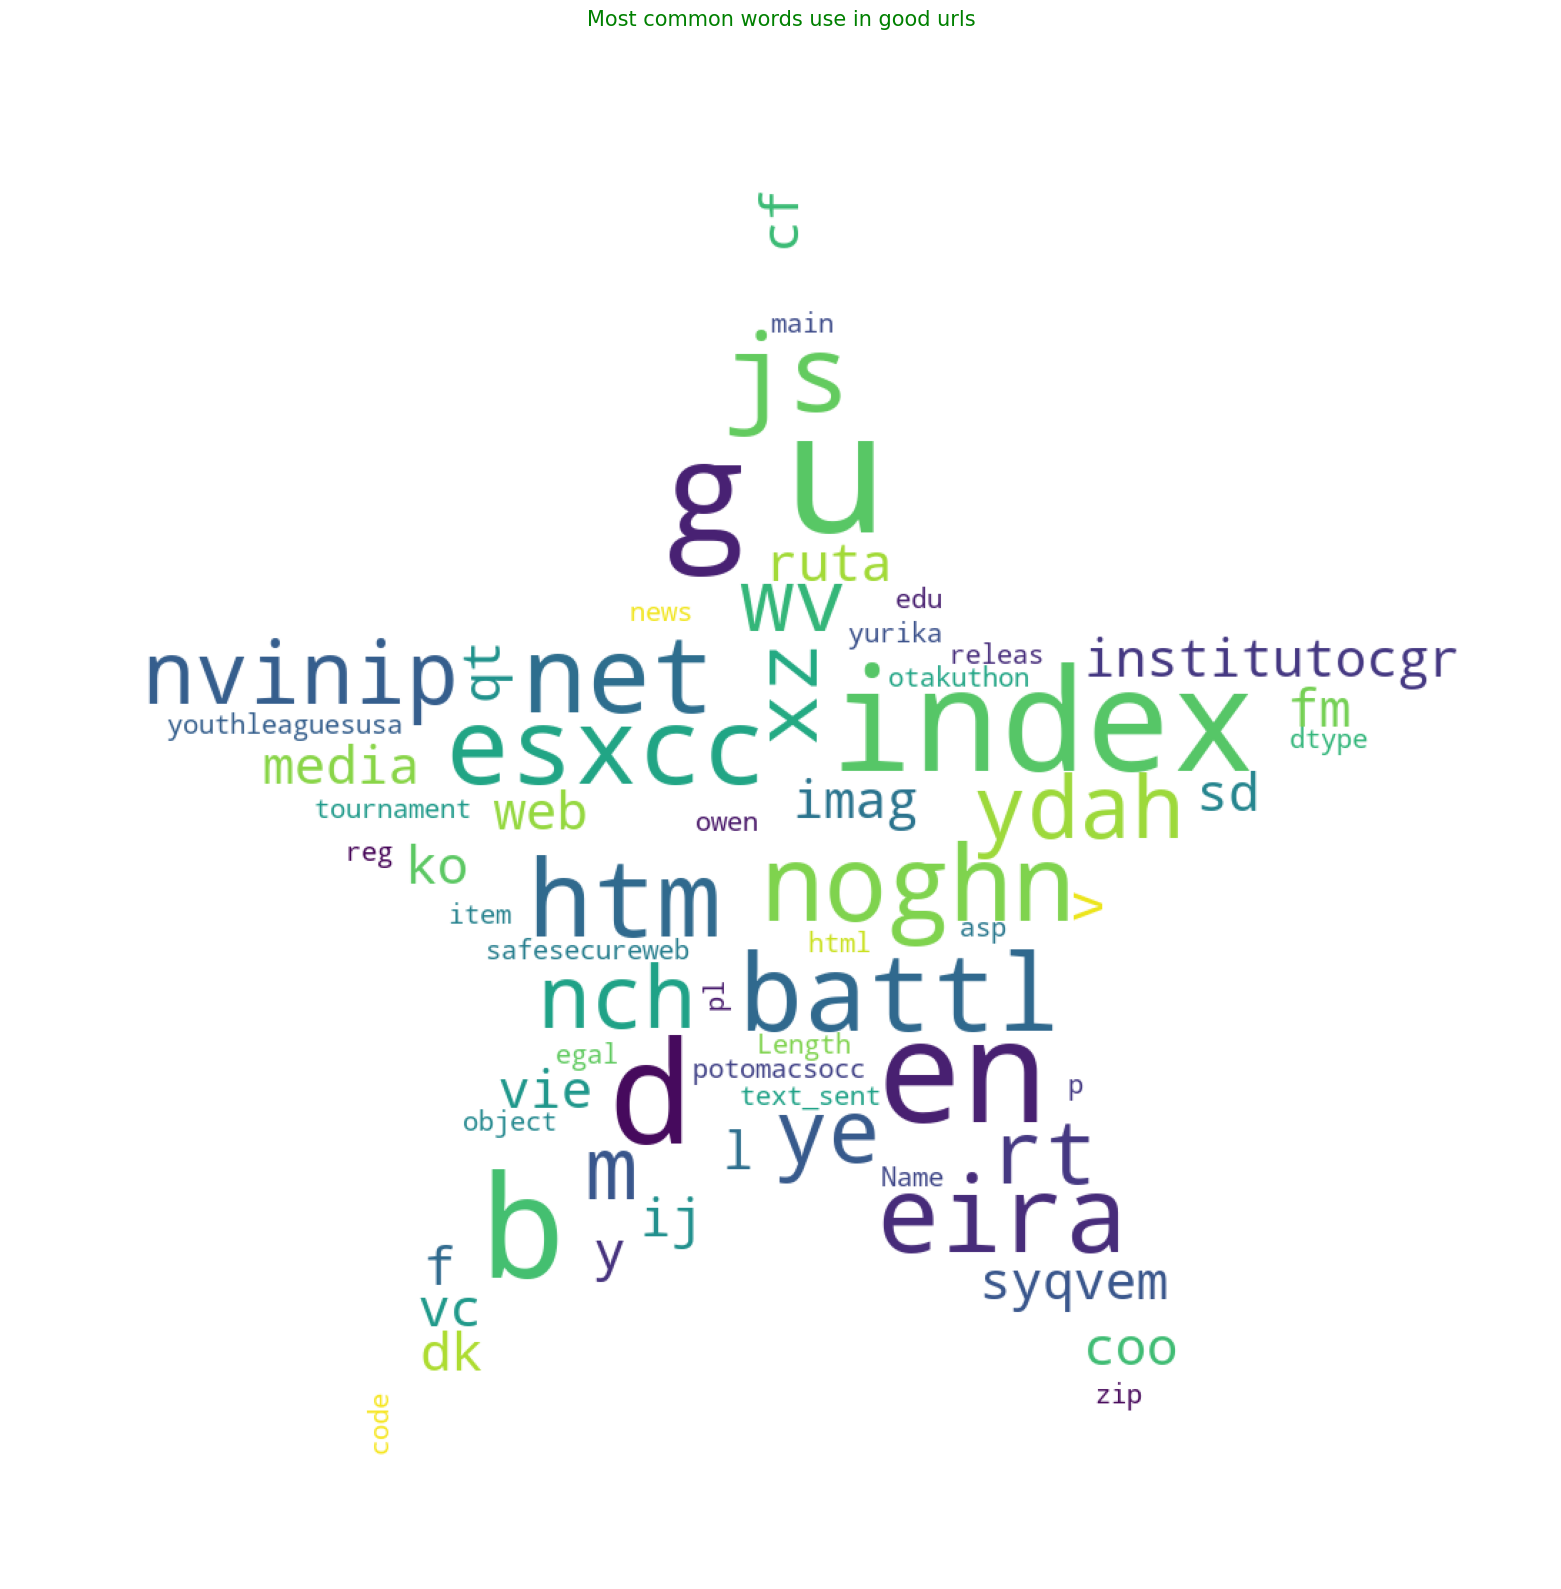

In [35]:
nltk.download('stopwords')
from wordcloud import WordCloud
from wordcloud import STOPWORDS
common_text = str(data)
common_mask = np.array(Image.open('star.png'))
plot_wordcloud(common_text, common_mask, max_words=400, max_font_size=120, 
               title = 'Most common words use in good urls', title_size=15)

In [36]:
data = bad_sites.text_sent
data.reset_index(drop=True, inplace=True)

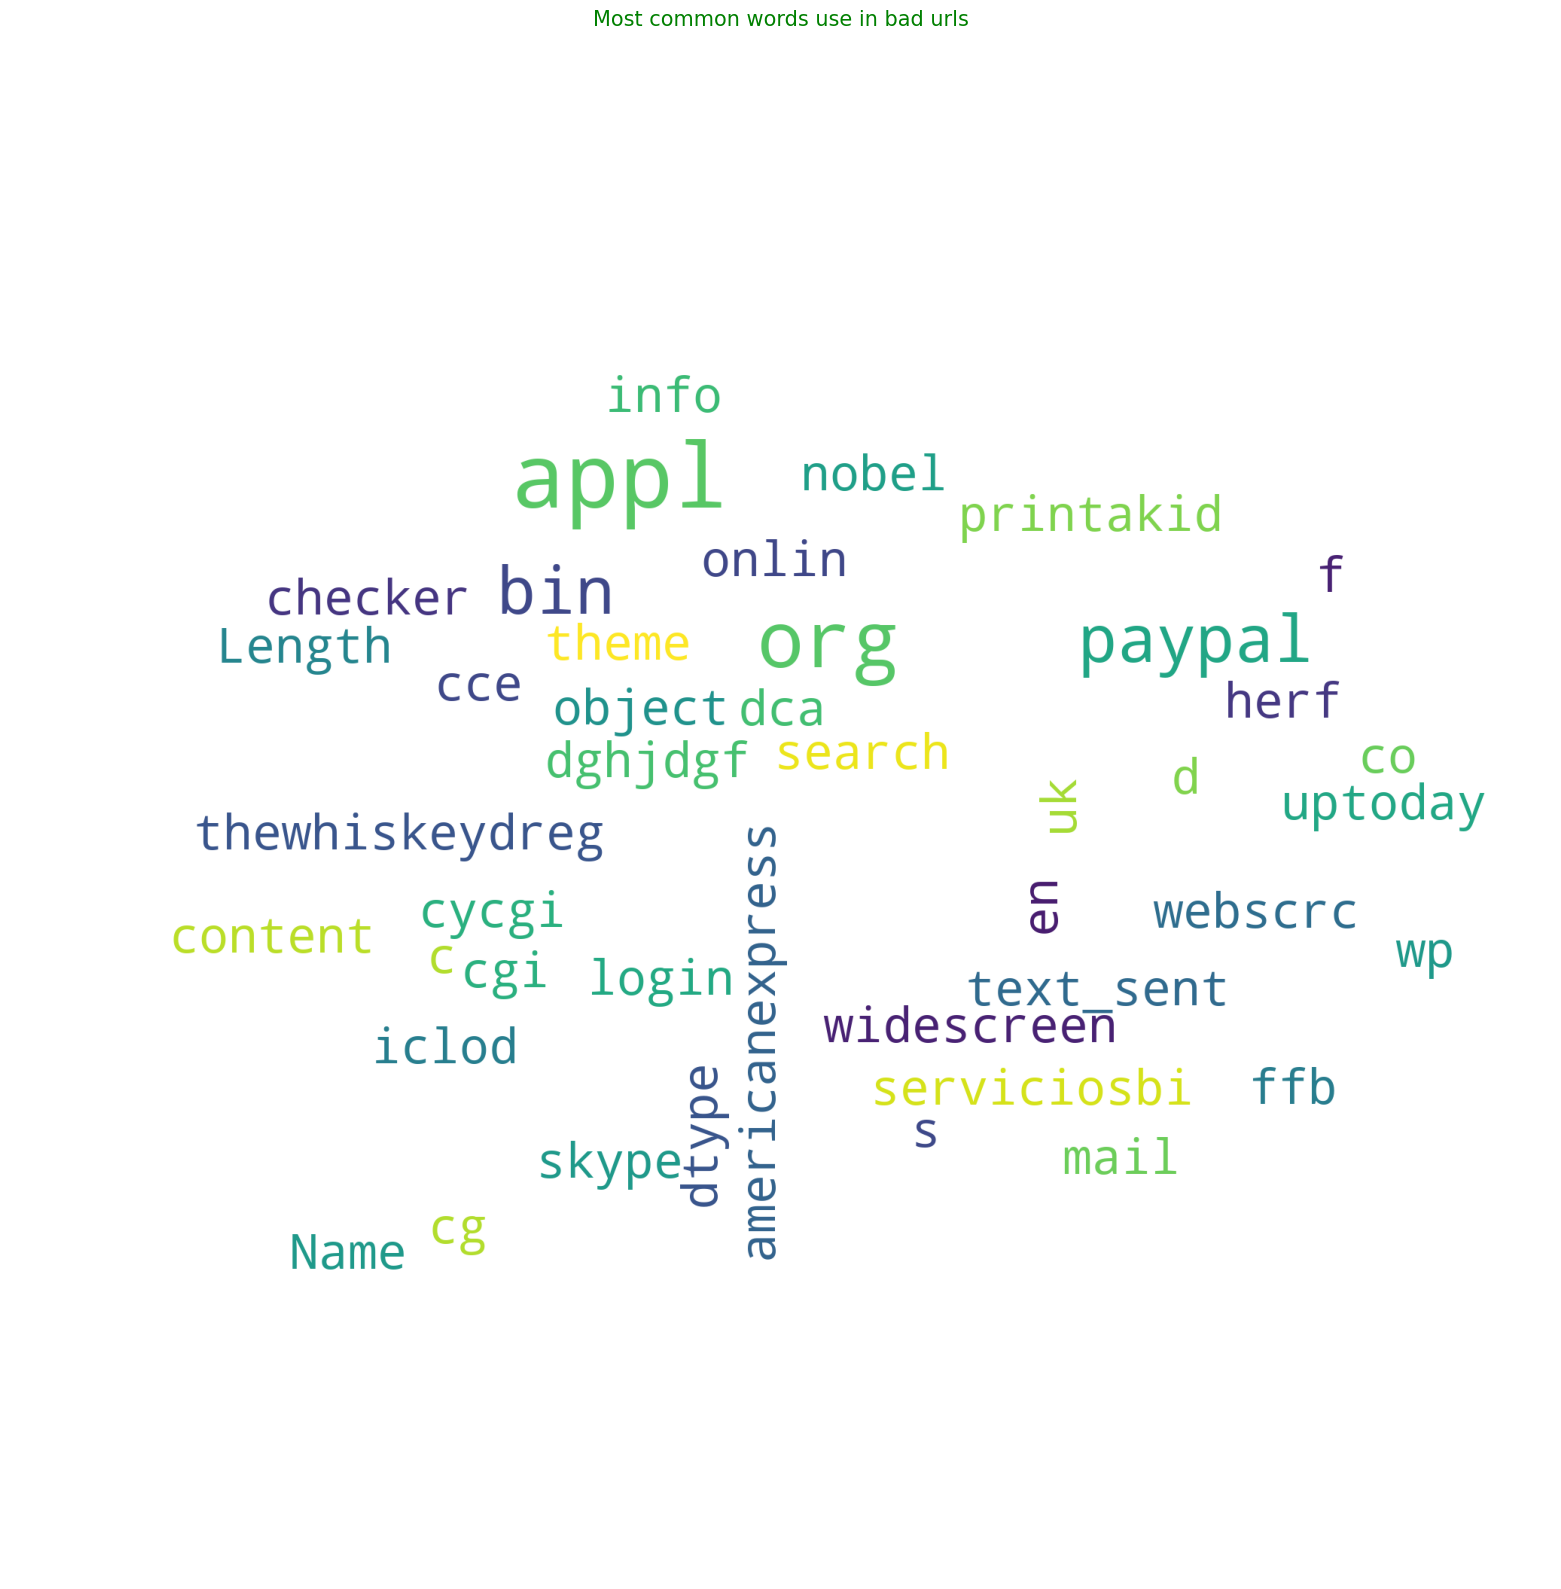

In [37]:
common_text = str(data)
common_mask = np.array(Image.open('comment.png'))
plot_wordcloud(common_text, common_mask, max_words=400, max_font_size=120, 
               title = 'Most common words use in bad urls', title_size=15)

In [113]:
from bs4 import BeautifulSoup # use for scraping the data from website
from selenium import webdriver # use for automation chrome 
import networkx as nx # for the creation, manipulation, and study of the structure, dynamics, and functions of complex networks.


In [114]:
browser = webdriver.Chrome()

In [115]:
list_urls = ['http://cbic.fallguys.biz'] #here i take demo phising sites(data uploaded from https://www.phishtank.com/)
links_with_text = []

In [116]:
for url in list_urls:
    browser.get(url)
    soup = BeautifulSoup(browser.page_source,"html.parser")
    for line in soup.find_all('a'):
        href = line.get('href')
        links_with_text.append([url, href])

In [117]:
df = pd.DataFrame(links_with_text, columns=["from", "to"])

In [118]:
df.head()


,from,to
0,http://cbic.fallguys.biz,https://store.epicgames.com/en-US/p/fall-guys
1,http://cbic.fallguys.biz,https://store.playstation.com/en-us/product/UP...
2,http://cbic.fallguys.biz,https://www.nintendo.com/store/products/fall-g...
3,http://cbic.fallguys.biz,https://www.xbox.com/en-us/games/store/fall-g...
4,http://cbic.fallguys.biz,/download


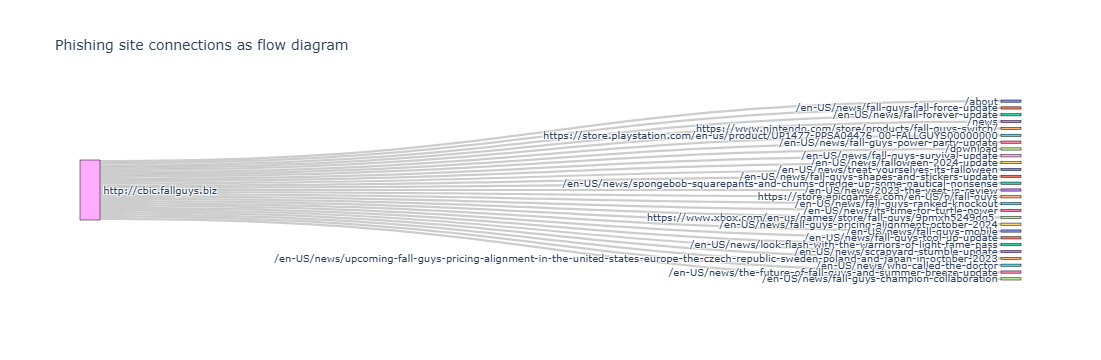

In [127]:
import plotly.graph_objects as go
import networkx as nx

# You already have GA created from your DataFrame
# GA = nx.from_pandas_edgelist(df, source="from", target="to")

# Create Sankey data
source_indices = []
target_indices = []
node_labels = list(set([n for e in GA.edges() for n in e]))
node_dict = {node: i for i, node in enumerate(node_labels)}

for s, t in GA.edges():
    source_indices.append(node_dict[s])
    target_indices.append(node_dict[t])

fig = go.Figure(data=go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=node_labels
    ),
    link=dict(
        source=source_indices,
        target=target_indices,
        value=[1]*len(source_indices)  # Equal weight for all connections
    )
))

fig.update_layout(title_text="Phishing site connections as flow diagram", font_size=10)
fig.show()

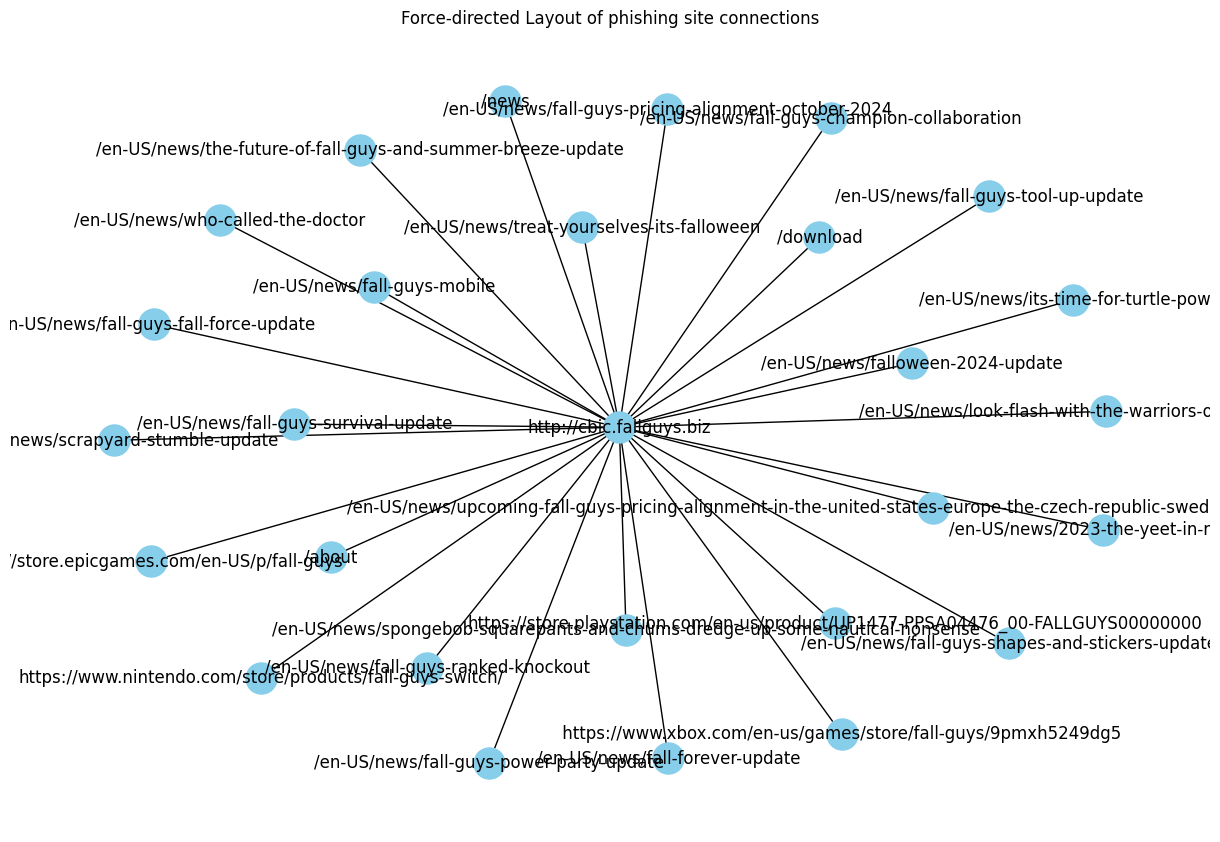

In [130]:
import networkx as nx
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
pos = nx.spring_layout(GA)
nx.draw(GA, pos, with_labels=True, node_color='skyblue', node_size=500, arrows= True)
plt.title("Force-directed Layout of phishing site connections")
plt.tight_layout()
plt.show()

In [38]:
from sklearn.model_selection import train_test_split # spliting the data between feature and target
from sklearn.metrics import classification_report # gives whole report about metrics 
from sklearn.metrics import confusion_matrix # gives info about actual and predict
from nltk.tokenize import RegexpTokenizer # regexp tokenizers use to split words from text  
from nltk.stem.snowball import SnowballStemmer # stemmes words
from sklearn.feature_extraction.text import CountVectorizer # create sparse matrix of words using regexptokenizes  
from sklearn.pipeline import make_pipeline # use for combining all prerocessors techniuqes and algos


In [39]:
phish_data['Label'].value_counts()

Label
good    392924
bad     156422
Name: count, dtype: int64

In [40]:
#create cv object
cv = CountVectorizer()

In [41]:
feature = cv.fit_transform(phish_data.text_sent) #transform all text which we tokenize and stemed

In [42]:
feature[:5].toarray() 

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int64)

In [43]:
trainX, testX, trainY, testY = train_test_split(feature, phish_data.Label)

In [44]:
from sklearn.linear_model import LogisticRegression # algo use to predict good or bad
from sklearn.naive_bayes import MultinomialNB # nlp algo use to predict good or bad
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB,BernoulliNB

In [45]:
# create lr object
lr = LogisticRegression()

In [46]:
lr.fit(trainX,trainY)

LogisticRegression()

In [47]:
lr.score(testX,testY)

0.9633529201890241

In [48]:
#here logistic regression is giving 96% accuracy 
#Now will store the scores and see which model perform the best  

In [49]:
Scores_ml = {}
Scores_ml['Logistic Regression'] = np.round(lr.score(testX,testY),2)

Training Accuracy : 0.9776194209349796
Testing Accuracy : 0.9633529201890241

CLASSIFICATION REPORT

              precision    recall  f1-score   support

         Bad       0.91      0.96      0.93     36847
        Good       0.99      0.96      0.97    100490

    accuracy                           0.96    137337
   macro avg       0.95      0.96      0.95    137337
weighted avg       0.96      0.96      0.96    137337


CONFUSION MATRIX


<Axes: >

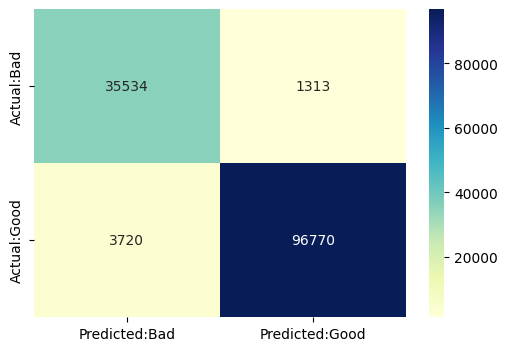

In [50]:
print('Training Accuracy :',lr.score(trainX,trainY))
print('Testing Accuracy :',lr.score(testX,testY))
con_mat = pd.DataFrame(confusion_matrix(lr.predict(testX), testY),
            columns = ['Predicted:Bad', 'Predicted:Good'],
            index = ['Actual:Bad', 'Actual:Good'])


print('\nCLASSIFICATION REPORT\n')
print(classification_report(lr.predict(testX), testY,
                            target_names =['Bad','Good']))

print('\nCONFUSION MATRIX')
plt.figure(figsize= (6,4))
sns.heatmap(con_mat, annot = True,fmt='d',cmap="YlGnBu")

In [51]:
# Now we will see the accuracy for MultinomialNB
mnb = MultinomialNB()

In [52]:
mnb.fit(trainX,trainY)

MultinomialNB()

In [53]:
mnb.score(testX,testY)

0.9571928904810794

In [54]:
#Multinomial is giving the accuracy of 95%

In [55]:
Scores_ml['MultinomialNB'] = np.round(mnb.score(testX,testY),2)

Training Accuracy : 0.9742481353562665
Testing Accuracy : 0.9571928904810794

CLASSIFICATION REPORT

              precision    recall  f1-score   support

         Bad       0.91      0.93      0.92     38405
        Good       0.97      0.97      0.97     98932

    accuracy                           0.96    137337
   macro avg       0.94      0.95      0.95    137337
weighted avg       0.96      0.96      0.96    137337


CONFUSION MATRIX


<Axes: >

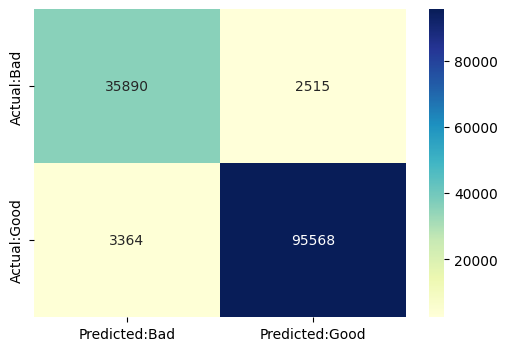

In [56]:
print('Training Accuracy :',mnb.score(trainX,trainY))
print('Testing Accuracy :',mnb.score(testX,testY))
con_mat = pd.DataFrame(confusion_matrix(mnb.predict(testX), testY),
            columns = ['Predicted:Bad', 'Predicted:Good'],
            index = ['Actual:Bad', 'Actual:Good'])


print('\nCLASSIFICATION REPORT\n')
print(classification_report(mnb.predict(testX), testY,
                            target_names =['Bad','Good']))

print('\nCONFUSION MATRIX')
plt.figure(figsize= (6,4))
sns.heatmap(con_mat, annot = True,fmt='d',cmap="YlGnBu")

In [53]:
bnb = BernoulliNB()

In [62]:
bnb.fit(trainX,trainY)

BernoulliNB()

In [260]:
bnb.score(testX,testY)

0.9418583484421532

In [261]:
#gnb = GaussianNB()
#data is too dense for gaussianNB

In [265]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [54]:
from xgboost import XGBClassifier
from sklearn.feature_extraction.text import TfidfVectorizer

In [55]:
xg = XGBClassifier()

In [56]:
xg.fit(trainX,trainY)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [57]:
xg.score(testX,testY)

0.9148299438607221

In [58]:
Scores_ml['XGBClassifier'] = np.round(xg.score(testX,testY),2)

Training Accuracy : 0.9153198109750029
Testing Accuracy : 0.9148299438607221

CLASSIFICATION REPORT

              precision    recall  f1-score   support

         Bad       0.98      0.91      0.94    106106
        Good       0.75      0.94      0.83     31231

    accuracy                           0.91    137337
   macro avg       0.87      0.92      0.89    137337
weighted avg       0.93      0.91      0.92    137337


CONFUSION MATRIX


<Axes: >

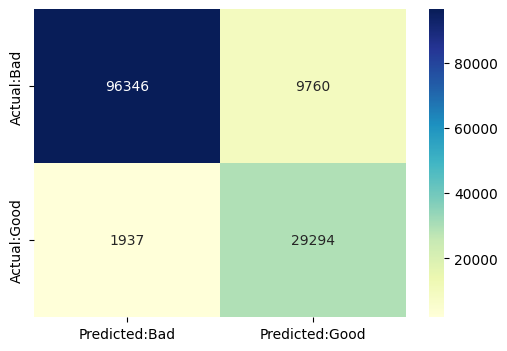

In [59]:
print('Training Accuracy :',xg.score(trainX,trainY))
print('Testing Accuracy :',xg.score(testX,testY))
con_mat = pd.DataFrame(confusion_matrix(xg.predict(testX), testY),
            columns = ['Predicted:Bad', 'Predicted:Good'],
            index = ['Actual:Bad', 'Actual:Good'])


print('\nCLASSIFICATION REPORT\n')
print(classification_report(xg.predict(testX), testY,
                            target_names =['Bad','Good']))

print('\nCONFUSION MATRIX')
plt.figure(figsize= (6,4))
sns.heatmap(con_mat, annot = True,fmt='d',cmap="YlGnBu")

In [ ]:
##Here i have combine all the ML algorithm into one 
#it was to improve the accuracy of the program

In [281]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import BernoulliNB, MultinomialNB

ensemble = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression()),
        ('bnb', BernoulliNB()),
        ('xg', XGBClassifier()),
        ('mnb', MultinomialNB())
    ],
    voting='soft'  # Use probabilities for better performance
)
ensemble.fit(trainX, trainY)

VotingClassifier(estimators=[('lr', LogisticRegression()),
                             ('bnb', BernoulliNB()),
                             ('xg',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None, gamma=None,
                                            grow_policy=None,
                                            importance_t...
                                            interaction_constraints=None,
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=None, n_jobs=None,
                                            num_parallel_tree=None,
                                            random_state=None, ...)),
                             ('mnb', MultinomialNB())],
                 voting='soft')

In [282]:
test_accuracy = ensemble.score(testX, testY)
print(f"Ensemble Test Accuracy: {test_accuracy * 100:.2f}%")

Ensemble Test Accuracy: 95.56%


In [ ]:
#from imblearn.ensemble import BalancedRandomForestClassifier

#brf = BalancedRandomForestClassifier(
   # n_estimators=100,
    #sampling_strategy='auto',  # Balances classes
    #replacement=True,          # Bootstrap sampling
    #random_state=42
#)
#brf.fit(trainX, trainY)

In [63]:
#from sklearn.svm import SVC


In [64]:
#sv = SVC(kernel='linear')

In [65]:
#from scipy.sparse import issparse
#print(issparse(trainX))  # If True, you're dealing with sparse matrix


True


In [66]:
#from sklearn.preprocessing import MaxAbsScaler

#scaler = MaxAbsScaler()
#trainX_scaled = scaler.fit_transform(trainX)
t#estX_scaled = scaler.transform(testX)


In [ ]:
#sv.fit(trainX,trainY)

In [ ]:
#0sv.score(testX,testY)

In [274]:
# So, we combine both the models to improve accuracy, Now we make sklearn pipeline using combined

In [85]:
pipeline_ls.fit(trainX, trainY)
print("Test Accuracy:", pipeline_ls.score(testX, testY))

Test Accuracy: 0.9065258942386457


In [ ]:
#But the accuracy was still 90% so i ditched and move towards the logistic regression model 

In [57]:
pipeline_ls = make_pipeline(CountVectorizer(tokenizer = RegexpTokenizer(r'[A-Za-z]+').tokenize,stop_words='english'), LogisticRegression())


In [58]:
trainX, testX, trainY, testY = train_test_split(phish_data.URL, phish_data.Label)

In [59]:
pipeline_ls.fit(trainX,trainY)

Pipeline(steps=[('countvectorizer',
                 CountVectorizer(stop_words='english',
                                 tokenizer=<bound method RegexpTokenizer.tokenize of RegexpTokenizer(pattern='[A-Za-z]+', gaps=False, discard_empty=True, flags=re.UNICODE|re.MULTILINE|re.DOTALL)>)),
                ('logisticregression', LogisticRegression())])

In [60]:
pipeline_ls.score(testX,testY) 

0.9662945892221324

Training Accuracy : 0.9806751794256922
Testing Accuracy : 0.9662945892221324

CLASSIFICATION REPORT

              precision    recall  f1-score   support

         Bad       0.91      0.97      0.94     36882
        Good       0.99      0.97      0.98    100455

    accuracy                           0.97    137337
   macro avg       0.95      0.97      0.96    137337
weighted avg       0.97      0.97      0.97    137337


CONFUSION MATRIX


<Axes: >

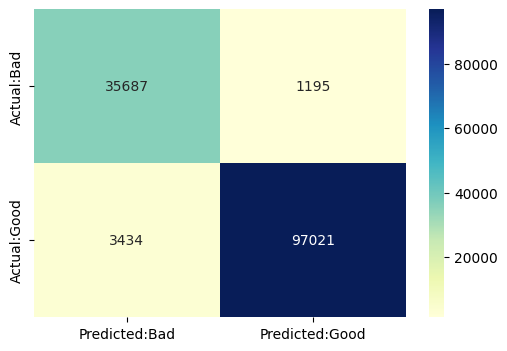

In [61]:
print('Training Accuracy :',pipeline_ls.score(trainX,trainY))
print('Testing Accuracy :',pipeline_ls.score(testX,testY))
con_mat = pd.DataFrame(confusion_matrix(pipeline_ls.predict(testX), testY),
            columns = ['Predicted:Bad', 'Predicted:Good'],
            index = ['Actual:Bad', 'Actual:Good'])


print('\nCLASSIFICATION REPORT\n')
print(classification_report(pipeline_ls.predict(testX), testY,
                            target_names =['Bad','Good']))

print('\nCONFUSION MATRIX')
plt.figure(figsize= (6,4))
sns.heatmap(con_mat, annot = True,fmt='d',cmap="YlGnBu")

In [62]:
from transformers import pipeline
import pickle


In [63]:
pickle.dump(pipeline_ls,open('phishing.pkl','wb'))

In [64]:
loaded_model = pickle.load(open('phishing.pkl', 'rb'))
result = loaded_model.score(testX,testY)
print(result)

0.9662945892221324


In [65]:
predict_bad = ['yeniik.com.tr/wp-admin/js/login.alibaba.com/login.jsp.php','fazan-pacir.rs/temp/libraries/ipad','tubemoviez.exe','svision-online.de/mgfi/administrator/components/com_babackup/classes/fx29id1.txt']
predict_good = ['youtube.com/','youtube.com/watch?v=qI0TQJI3vdU','retailhellunderground.com/','restorevisioncenters.com/html/technology.html']
loaded_model = pickle.load(open('phishing.pkl', 'rb'))
#predict_bad = vectorizers.transform(predict_bad)
# predict_good = vectorizer.transform(predict_good)
result = loaded_model.predict(predict_bad)
result2 = loaded_model.predict(predict_good)
print(result)
print("*"*30)
print(result2)

['bad' 'bad' 'bad' 'bad']
******************************
['good' 'good' 'good' 'good']


In [66]:
import gradio as gr

In [68]:
import gradio as gr
import joblib

phish_model = open('phishing.pkl', 'rb')
phish_model_ls = joblib.load(phish_model)

def predict_url(url):
    try:
        prediction = phish_model_ls.predict([url])
        if prediction[0] == 'bad':
            return "⚠️ This is a Phishing Site"
        else:
            return "✅ This is a safe Site"
    except Exception as e:
        return f"❌ Error: {str(e)}"

# Create Gradio interface
app = gr.Interface(
    fn=predict_url,
    inputs=gr.Textbox(label="Enter a URL to Check"),
    outputs=gr.Textbox(label="Prediction Result"),
    title="🔒 Phishing URL Detector",
    description="Enter a website link. This tool will predict whether the link is safe or a phishing attempt."
)

# Launch the Gradio app
app.launch(share=True)


* Running on local URL:  http://127.0.0.1:7861
* Running on public URL: https://ad8e7b7fd3053b77d0.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
